# Calculation general CME distributions for a fast rotation star. 

## the interesting quantity now is the dopplershift in the direction of the observer

The velocity component of the CME in direction of the observer, 
$$ v \cos \beta = v (\cos \theta \cos \theta' + \sin \theta\sin \theta' \cos \phi') $$
will now be supplemented by a component comming from the rotation of the star itself, namely 
$$\omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta,$$
where $\omega (\alpha)$ is the angular frequency at lattitude $\alpha$ and $R$ is the radius of the star, which we assume to be constant. 
For a rigid rotator $\omega (\alpha) = \omega$, for the solar case this has been observed to obey some relation of the form $\omega (\alpha) = A + B \sin^2 + C \sin^4$. The assumption that the fast rotator is a perfect sphere can be corrected by taking $R(\alpha)$ insteand where the radius can vary with lattitude. 

In order for this correction to be significant, the order of magnitude of $\omega R$ should be on the order of the velocity of a CME $v$. In the solar case, this correction will be neglegtible. 

To solve for the distribution in dopplershift $d$ in direction of the observer, we solve following integral
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [2]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

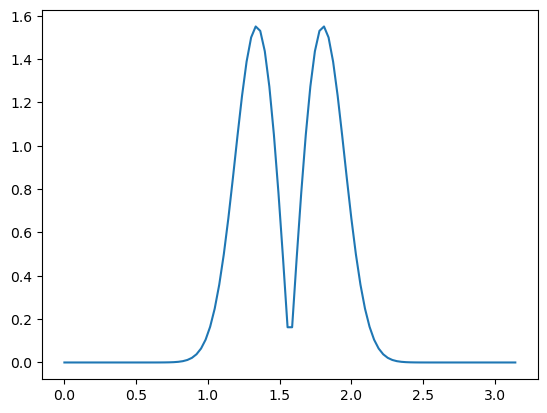

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$
For a proper description we refer to the associated paper.



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. We here under properly normalize the distribution!

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

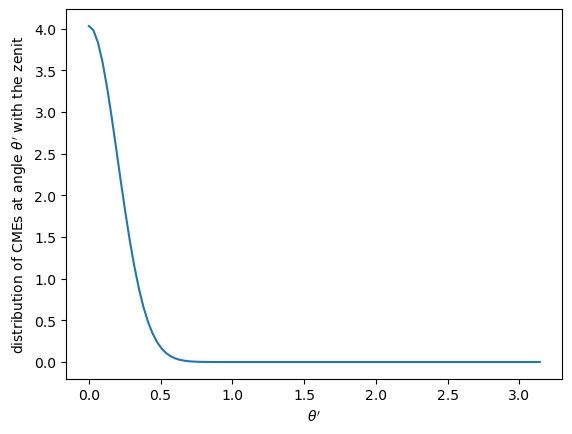

In [4]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta ).
\end{equation}

so we use $d = v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) + \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta$, or equivalently that
$\cos \phi' = \frac{d- v\cos\theta'\cos\theta - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta}{v\sin \theta'\sin\theta}$
to find that 

# Check this again! seems reversed! (in the old ones)

\begin{equation}
    \int d\phi'   \delta(d - v ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta) - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta) = \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 

\begin{equation}
    \rho_d(d) = \frac{1}{N} \int \sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi))  \sin\theta' d\theta'  \rho^{CME}(\theta') \frac{1}{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}.
\end{equation}
Hence, 
\begin{equation}
    \rho_d(d) = \frac{1}{N} \int  d\theta d\phi  d\theta'  \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta') \frac{1}{\sin\phi'(\theta, \theta',\beta)}.
\end{equation}


# intergral numerical

## rigid rotator satisfying 
$$\omega R = v$$

In [5]:
import time
from scipy.integrate import nquad
omega = 1
v = 1
R = 1

# general distribution for given tau
def get_sinphi2(cosphi2):
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_cosphi2(theta, phi, theta2, dop, tau):
    # \frac{d- v\cos\theta'\cos\theta - \omega (\alpha) R \sin \tau \sin \sin \phi \sin \theta}{v\sin \theta'\sin\theta}
    return (dop - v * np.cos(theta) * np.cos(theta2) - omega * R * np.sin(tau) * np.sin(phi) * np.sin(theta))/ (v * np.sin(theta) * np.sin(theta2)) 

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(dop, tau):
    def integrand2(theta, phi, theta2):
        return integrand(theta, phi, theta2, dop, tau)
    return integrand2

def integrand(theta, phi, theta2, dop, tau):
    cosphi2 = get_cosphi2(theta, phi, theta2, dop, tau)
    sinphi2 = get_sinphi2(cosphi2)
    alpha = get_alpha(tau, theta, phi)
    return    np.where(np.abs(cosphi2) >1, 0,  
            np.sin(theta) * rho(alpha) * np.sin(theta2) * rho_CME(theta2) / (sinphi2 + 0.001) )


def get_rho_dop(dop, tau):
    start_time = time.time()
    print(dop, tau, end='\r')
    result, error = nquad(f_integrand_(dop, tau), [[0, np.pi],       # theta, phi, theta2
                                                [0, 2*np.pi],         # phi
                                                [0, np.pi / 2 ]], opts={"epsrel":0.05, 'epsabs':1e-2})       # theta2
    end_time = time.time()
    print(f'For params {dop=}, {tau = } we find the distibution to be {result }, with estimated error {error}. \
        Taking {(end_time-start_time):.2f} to calculate.')

    return result


def rho_dops(dops, tau):
    return np.array([get_rho_dop(dop, tau) for dop in dops])

dops = np.linspace(-2,2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)


def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_dops(dops, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"incoming velocity in units of  [$v$]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return np.array(dens)






In [ ]:
from pathlib import Path

def get_or_create_data(name):
    filename = f'calculations/{name}_rotation.npy'
    file_path = Path(filename)

    
    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        # Replace this with your actual data generation logic
        data = run_taus(Taus)
        
        # Save the file so it exists next time
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")
        
    return data

dens = get_or_create_data("sundist")


File 'calculations/sundist_rotation.npy' not found. Creating new data...
calculating tau = 0.0
For params dop=np.float64(-2.0), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.         Taking 1.60 to calculate.
For params dop=np.float64(-1.7894736842105263), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.         Taking 1.28 to calculate.
For params dop=np.float64(-1.5789473684210527), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.         Taking 1.20 to calculate.
For params dop=np.float64(-1.368421052631579), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.         Taking 1.16 to calculate.
For params dop=np.float64(-1.1578947368421053), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.         Taking 1.03 to calculate.
For params dop=np.float64(-0.9473684210526316), tau = np.float64(0.0) we find the distibution to be 0.0005

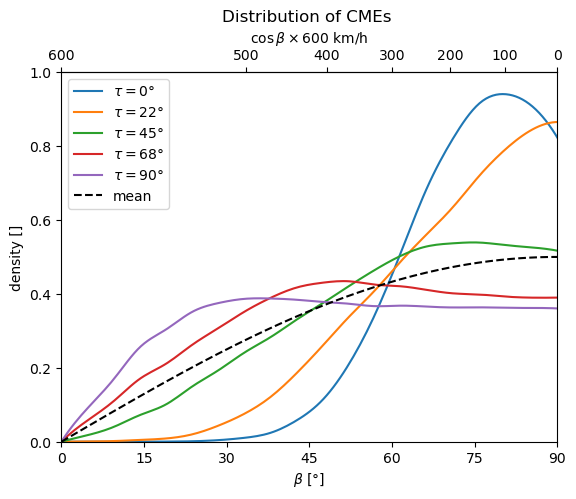

In [ ]:


from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



numerical (not yet enough accruracy)
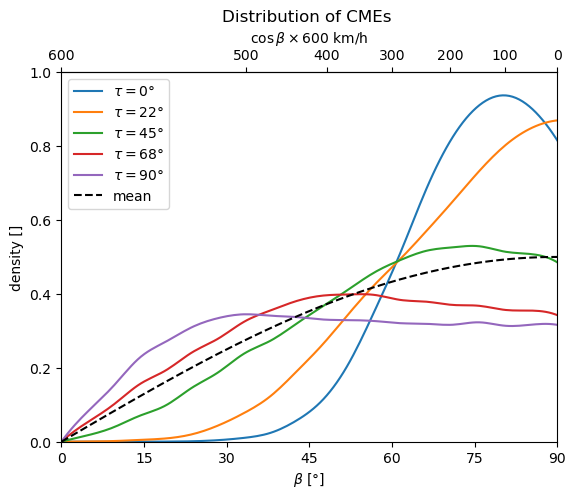

Monte carlo (with sin at 0)
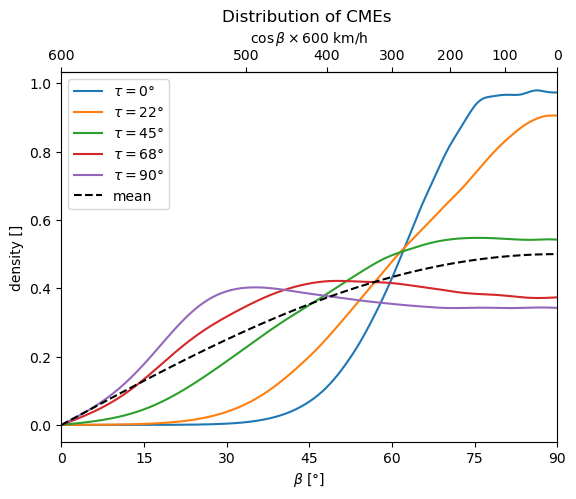


# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

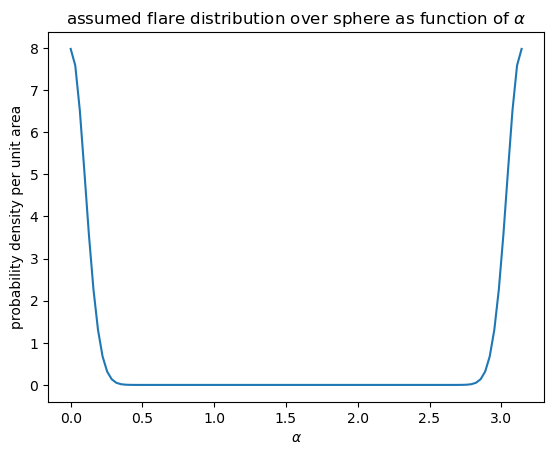

In [9]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [10]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()


0.0 (0.9993158136231646, 3.647190528409362e-12)
0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)
0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)
1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)
1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


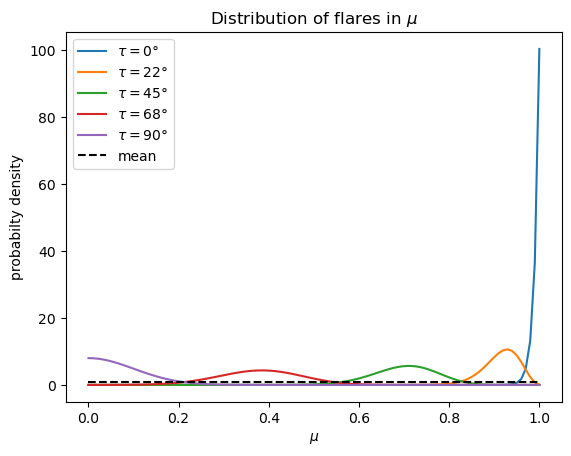

File 'calculations/polardist.npy' not found. Creating new data...
calculating tau = 0.0
For params beta=np.float64(0.0), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.0.         Taking 5.99 to calculate.
For params beta=np.float64(0.08267349088394192), tau = np.float64(0.0) we find the distibution to be 0.003040989195648208, with estimated error 0.005162037381999687.         Taking 41.13 to calculate.
For params beta=np.float64(0.16534698176788384), tau = np.float64(0.0) we find the distibution to be 0.0048052647760048585, with estimated error 0.006693128125178607.         Taking 47.81 to calculate.
For params beta=np.float64(0.24802047265182575), tau = np.float64(0.0) we find the distibution to be 0.005329370166732306, with estimated error 0.0064959687805395145.         Taking 44.09 to calculate.
For params beta=np.float64(0.3306939635357677), tau = np.float64(0.0) we find the distibution to be 0.004262395528153808, with estimated error 0.005053657229

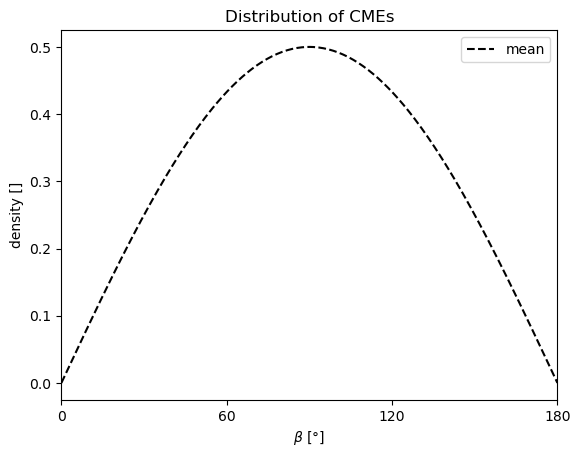

Data saved to 'calculations/polardist.npy'.


In [11]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("polardist")


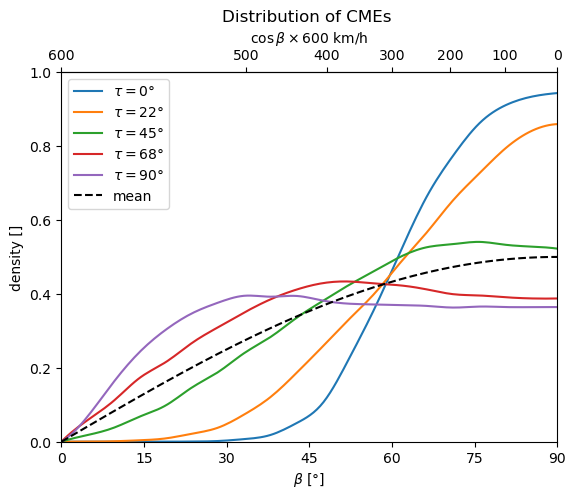

In [20]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



# flares around Equator (normal dist, no dip)

Text(0, 0.5, 'probability density per unit area')

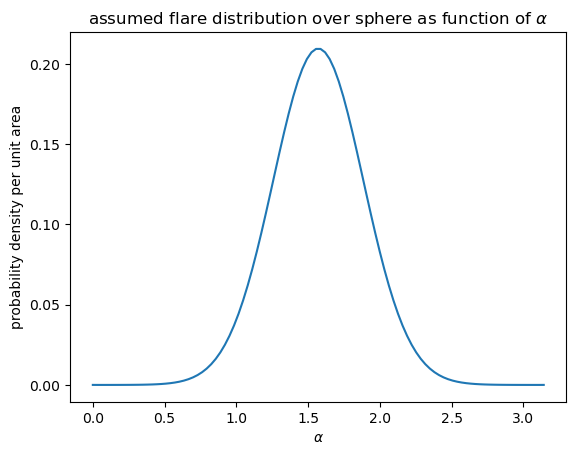

In [13]:
from scipy.stats import norm

def rho(alpha, loc=np.pi/2, scale = 0.3, err = 0.01):
    return norm.pdf(alpha, loc, scale) / 2 / np.pi / (np.sin(alpha) + err) 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.9895962000276162, 5.042964046353404e-09)
0.39269908169872414 (0.9895961988532547, 1.516983175045775e-09)
0.7853981633974483 (0.9895962002095553, 4.501296178332404e-09)
1.1780972450961724 (0.9895961876136867, 4.098245470594385e-09)


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_2056\1622699827.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return 2 * quad(I, 0, 2*np.pi)[0]


1.5707963267948966 (0.989596200117882, 1.343628143600427e-11)


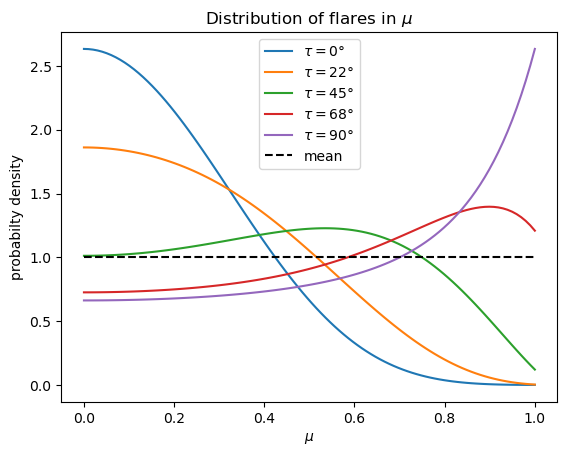

File 'calculations/equatornormaldist.npy' not found. Creating new data...
calculating tau = 0.0
For params beta=np.float64(0.0), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.0.         Taking 2.77 to calculate.
For params beta=np.float64(0.08267349088394192), tau = np.float64(0.0) we find the distibution to be 5.279719531125849e-06, with estimated error 5.107861508129019e-06.         Taking 23.03 to calculate.
For params beta=np.float64(0.16534698176788384), tau = np.float64(0.0) we find the distibution to be 1.5970210235307615e-05, with estimated error 1.1190427908708653e-05.         Taking 8.84 to calculate.
For params beta=np.float64(0.24802047265182575), tau = np.float64(0.0) we find the distibution to be 3.841150546323612e-05, with estimated error 2.4109156133278014e-05.         Taking 8.99 to calculate.
For params beta=np.float64(0.3306939635357677), tau = np.float64(0.0) we find the distibution to be 6.65068841621566e-05, with estimated error 4

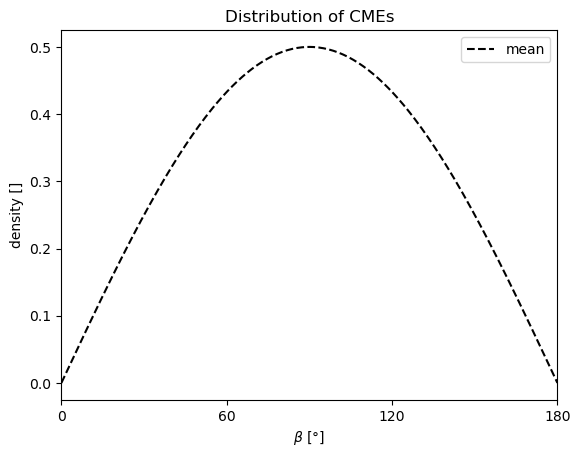

Data saved to 'calculations/equatornormaldist.npy'.


In [14]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("equatornormaldist")


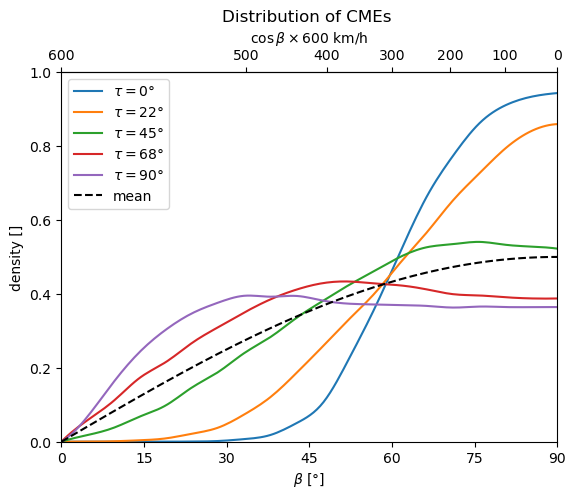

In [19]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



# Flares with stepfunction dist around equator

Text(0, 0.5, 'probability density per unit area')

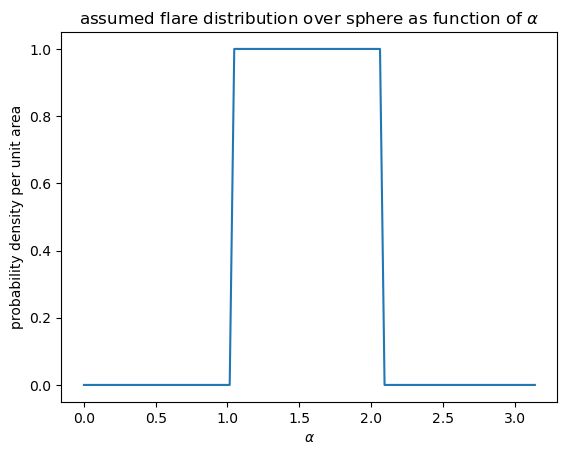

In [16]:
def rho(alpha, h=30/180*np.pi):
    return np.where(np.abs(alpha-np.pi/2) < h, 1, 0)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (6.283185307179586, 7.016609515630989e-14)


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_2056\1622699827.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(I, 0, 2*np.pi)[0]
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_2056\1622699827.py:25: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling 

0.39269908169872414 (6.283113268699922, 0.00014946526279637946)
0.7853981633974483 (6.28312602812515, 0.0024650655363972402)
1.1780972450961724 (6.282690892739802, 0.004444124139602046)
1.5707963267948966 (6.282738477965319, 0.002846612186670868)


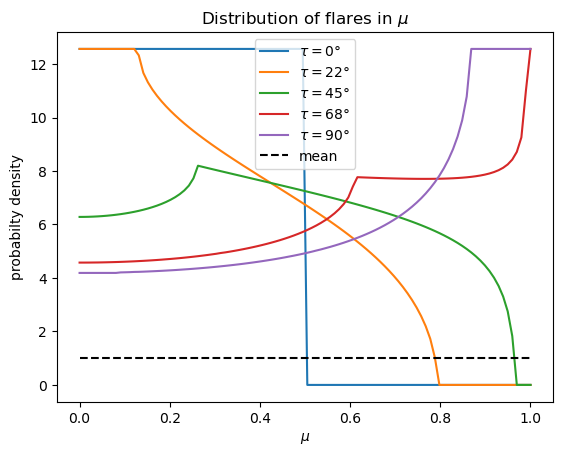

File 'calculations/blockdist.npy' not found. Creating new data...
calculating tau = 0.0
For params beta=np.float64(0.0), tau = np.float64(0.0) we find the distibution to be 0.0, with estimated error 0.0.         Taking 1.98 to calculate.
For params beta=np.float64(0.08267349088394192), tau = np.float64(0.0) we find the distibution to be 7.212313660326669e-08, with estimated error 2.6077808887297226e-07.         Taking 10.42 to calculate.
For params beta=np.float64(0.16534698176788384), tau = np.float64(0.0) we find the distibution to be 3.165761559193443e-07, with estimated error 1.1191880753363704e-06.         Taking 12.42 to calculate.
For params beta=np.float64(0.24802047265182575), tau = np.float64(0.0) we find the distibution to be 2.268989294972893e-06, with estimated error 7.738809101460497e-06.         Taking 11.01 to calculate.
For params beta=np.float64(0.3306939635357677), tau = np.float64(0.0) we find the distibution to be 1.313564133243939e-05, with estimated error 3.51207

c:\Users\mdewilde\AppData\Local\anaconda3\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


For params beta=np.float64(1.5707963267948966), tau = np.float64(1.5707963267948966) we find the distibution to be 0.039381508277668426, with estimated error 0.009976825386045196.         Taking 211.50 to calculate.


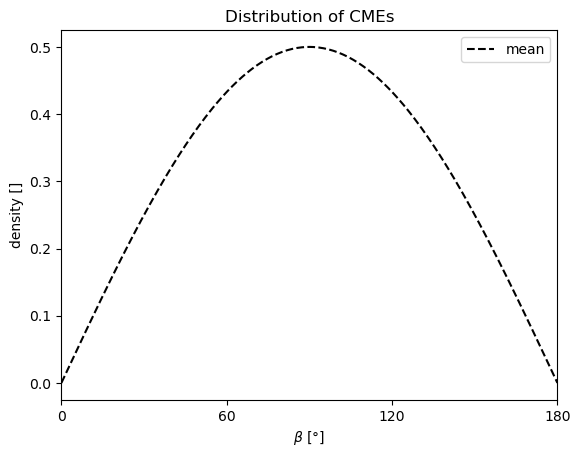

Data saved to 'calculations/blockdist.npy'.


In [17]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("blockdist")


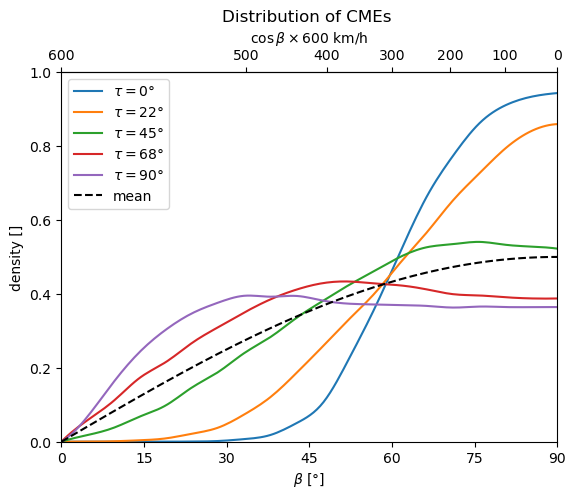

In [21]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)

